Data & Preprocessing

In [3]:
import pandas as pd
import re

In [4]:
cv = pd.read_csv("../data/small_cv.csv")
jobs = pd.read_csv("../data/small_jobs.csv")

print(cv.shape)
print(jobs.shape)

(30, 11)
(10, 10)


In [15]:
# Prepare examples from PDF, DOCX, and TXT formats
%pip install PyPDF2 python-docx
import PyPDF2
import docx
import os

def extract_text_from_file(file_path):
    ext = os.path.splitext(file_path)[1].lower()
    text = ""

    try:
        if ext == '.pdf':
            with open(file_path, 'rb') as f:
                reader = PyPDF2.PdfReader(f)
                for page in reader.pages:
                    if page.extract_text():
                        text += page.extract_text() + "\n"
        elif ext == '.docx':
            doc = docx.Document(file_path)
            for para in doc.paragraphs:
                text += para.text + "\n"
        elif ext == '.txt':
            with open(file_path, 'r', encoding='utf-8') as f:
                text = f.read()
        else:
            text = "Unsupported format."
    except Exception as e:
        text = f"Error reading file: {e}"

    return text

# TASK 5: Investigate parsing challenges
print("Loader ready. Note on parsing challenges: Complex PDFs with two-column layouts or nested tables often read out of order, jumbling Experience and Education dates.")

Note: you may need to restart the kernel to use updated packages.
Loader ready. Note on parsing challenges: Complex PDFs with two-column layouts or nested tables often read out of order, jumbling Experience and Education dates.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
print("RESUME:")
print(cv.loc[0, "resume_text"])

print("\nJOB DESCRIPTION:")
print(jobs.loc[0, "job_description"])

RESUME:
Target position: Senior Software Engineer Objective: Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with them. Currently in search of role that offers more of development. Skills: big data, hadoop, hive, python, mapreduce, spark, java, machine learning, cloud, hdfs, yarn, core java, data science, c++, data structures, dbms, rdbms, informatica, talend, amazon redshift, microsoft azure Education: ['B.Tech'] ['Electronics'] ['The Amity School of Engineering & Technology (ASET), Noida'] B.Sc in Computer Science & Engineering from a reputed university. Experience: At least 1 year ['Big Data Analyst'] Technical Support Troubleshooting Collaboration Documentation System Monitoring Software Deployment Training & Mentorship Industry Trends Field Visits Technical Support Troubleshooting Collaboration Documentation System Monitoring Software Deplo

In [17]:
# Check columns, data types, and non-null values

cv.info()

print("\n----------------------\n")

jobs.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   candidate_id       30 non-null     str    
 1   source_row         30 non-null     int64  
 2   target_position    30 non-null     str    
 3   resume_text        30 non-null     str    
 4   clean_skills       30 non-null     str    
 5   clean_skills_json  30 non-null     str    
 6   education_text     30 non-null     str    
 7   experience_text    30 non-null     str    
 8   years_experience   30 non-null     float64
 9   inferred_category  30 non-null     str    
 10  embedding          30 non-null     str    
dtypes: float64(1), int64(1), str(9)
memory usage: 2.7 KB

----------------------

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_id   

In [18]:
# Check if there are any missing values

print("CV missing values:")
print(cv.isnull().sum())

print("\nJob missing values:")
print(jobs.isnull().sum())

CV missing values:
candidate_id         0
source_row           0
target_position      0
resume_text          0
clean_skills         0
clean_skills_json    0
education_text       0
experience_text      0
years_experience     0
inferred_category    0
embedding            0
dtype: int64

Job missing values:
job_id               0
job_title            0
category             0
job_description      0
job_text             0
clean_skills         0
clean_skills_json    0
education_text       0
years_required       0
embedding            0
dtype: int64


In [19]:
# Check if there are duplicate rows

print("CV duplicates:", cv.duplicated().sum())
print("Job duplicates:", jobs.duplicated().sum())

CV duplicates: 0
Job duplicates: 0


In [20]:
# Remove duplicate rows

cv = cv.drop_duplicates()
jobs = jobs.drop_duplicates()

print("CV shape:", cv.shape)
print("Jobs shape:", jobs.shape)

CV shape: (30, 11)
Jobs shape: (10, 10)


In [21]:
# Replace missing resume or job text with an empty string

cv["resume_text"] = cv["resume_text"].fillna("")
jobs["job_description"] = jobs["job_description"].fillna("")

print("Missing resume text:", cv["resume_text"].isnull().sum())
print("Missing job text:", jobs["job_description"].isnull().sum())

Missing resume text: 0
Missing job text: 0


In [22]:
# Extract structured sections such as Skills, Education, and Experience
import re

def extract_resume_sections(text):
    text = str(text)
    sections = {'Experience': '', 'Education': '', 'Skills': ''}

    # Simple, readable regex capturing everything between standard headers
    exp_match = re.search(r"Experience(.*?)(Education|Skills|$)", text, re.IGNORECASE | re.DOTALL)
    edu_match = re.search(r"Education(.*?)(Experience|Skills|$)", text, re.IGNORECASE | re.DOTALL)
    skills_match = re.search(r"Skills(.*?)(Experience|Education|$)", text, re.IGNORECASE | re.DOTALL)

    if exp_match:
        sections['Experience'] = exp_match.group(1).strip()
    if edu_match:
        sections['Education'] = edu_match.group(1).strip()
    if skills_match:
        sections['Skills'] = skills_match.group(1).strip()

    return sections

# Apply to dataset
cv['structured_sections'] = cv['resume_text'].apply(extract_resume_sections)
print("Structured sections extracted successfully.")

Structured sections extracted successfully.


In [23]:
# Clean the text before using NLP

def clean_text(text):

    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove unwanted special characters
    text = re.sub(r"[^a-zA-Z0-9\s+#.]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [24]:
# Install NLTK for text preprocessing

%pip install nltk

  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/1.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.5/1.8 MB 1.5 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------- ---------------------- 0.8/1.8 MB 1.3 MB/s eta 0:00:01
   ----------------------- ---------------- 1.0/1.8 MB 1.2 MB/s eta 0:00:01
   ---------------------------------- ----- 1.6/1.8 MB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 1.4 MB/s eta 0:00:00
Using cached defusedxml-0.7.1-py2.py3-none-any.whl (25 kB)

   ------------- -------------------------- 1/3 [defusedxml]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [nltk]
   -------------------------- ------------- 2/3 [n


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# Import NLP tools

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer

In [26]:
# Install certificate package

%pip install certifi

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
# Fix SSL certificate path

import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()

In [28]:
# Download required NLTK resources

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\engom\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\engom\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\engom\AppData\Roaming\nltk_data...


True

In [29]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import RegexpTokenizer

tokenizer = RegexpTokenizer(r'[A-Za-z][A-Za-z0-9+#]*')
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [30]:
# Clean and normalize the text

def clean_text(text):

    # Convert text to lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove unwanted special characters
    text = re.sub(r"[^a-zA-Z0-9\s+#.]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [31]:
# Apply the cleaning function to resumes and job descriptions

cv["processed_resume"] = cv["resume_text"].apply(clean_text)

jobs["processed_job"] = jobs["job_description"].apply(clean_text)

In [32]:
# Compare the text before and after preprocessing

print("ORIGINAL RESUME:")
print(cv.loc[0, "resume_text"][:500])

print("\nCLEANED RESUME:")
print(cv.loc[0, "processed_resume"][:500])

print("\nORIGINAL JOB:")
print(jobs.loc[0, "job_description"][:500])

print("\nCLEANED JOB:")
print(jobs.loc[0, "processed_job"][:500])

ORIGINAL RESUME:
Target position: Senior Software Engineer Objective: Big data analytics working and database warehouse manager with robust experience in handling all kinds of data. I have also used multiple cloud infrastructure services and am well acquainted with them. Currently in search of role that offers more of development. Skills: big data, hadoop, hive, python, mapreduce, spark, java, machine learning, cloud, hdfs, yarn, core java, data science, c++, data structures, dbms, rdbms, informatica, talend, am

CLEANED RESUME:
target position senior software engineer objective big data analytics working and database warehouse manager with robust experience in handling all kinds of data. i have also used multiple cloud infrastructure services and am well acquainted with them. currently in search of role that offers more of development. skills big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science c++ data structures dbms rdbms informat

In [33]:
# Tokenize text, remove stop words, and lemmatize

def preprocess_nlp(text):

    tokens = tokenizer.tokenize(text)

    tokens = [word for word in tokens if word not in stop_words]

    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return tokens

In [34]:
# Apply NLP preprocessing

cv["tokens"] = cv["processed_resume"].apply(preprocess_nlp)
jobs["tokens"] = jobs["processed_job"].apply(preprocess_nlp)

In [35]:
# Display processed tokens

print("Resume Tokens:")
print(cv.loc[0, "tokens"][:50])

print("\nJob Tokens:")
print(jobs.loc[0, "tokens"][:50])

Resume Tokens:
['target', 'position', 'senior', 'software', 'engineer', 'objective', 'big', 'data', 'analytics', 'working', 'database', 'warehouse', 'manager', 'robust', 'experience', 'handling', 'kind', 'data', 'also', 'used', 'multiple', 'cloud', 'infrastructure', 'service', 'well', 'acquainted', 'currently', 'search', 'role', 'offer', 'development', 'skill', 'big', 'data', 'hadoop', 'hive', 'python', 'mapreduce', 'spark', 'java', 'machine', 'learning', 'cloud', 'hdfs', 'yarn', 'core', 'java', 'data', 'science', 'c++']

Job Tokens:
['apply', 'job', 'descriptionjob', 'title', 'director', 'financereports', 'ceo', 'svdp', 'detroitflsa', 'status', 'exempt', 'summarythe', 'society', 'st', 'vincent', 'de', 'paul', 'detroit', 'exists', 'build', 'equitable', 'compassionate', 'world', 'meaningful', 'personal', 'relationship', 'providing', 'whatever', 'needed', 'help', 'neighbor', 'get', 'back', 'foot', 'path', 'towards', 'self', 'sustainability', 'program', 'provide', 'support', 'ranging', 'u

In [36]:
# Join processed tokens back into text for later modeling

cv["final_processed_resume"] = cv["tokens"].apply(
    lambda x: " ".join(x)
)

jobs["final_processed_job"] = jobs["tokens"].apply(
    lambda x: " ".join(x)
)

In [37]:
# Display final processed text

print("FINAL RESUME TEXT:")
print(cv.loc[0, "final_processed_resume"][:500])

print("\nFINAL JOB TEXT:")
print(jobs.loc[0, "final_processed_job"][:500])

FINAL RESUME TEXT:
target position senior software engineer objective big data analytics working database warehouse manager robust experience handling kind data also used multiple cloud infrastructure service well acquainted currently search role offer development skill big data hadoop hive python mapreduce spark java machine learning cloud hdfs yarn core java data science c++ data structure dbms rdbms informatica talend amazon redshift microsoft azure education b tech electronics amity school engineering technolo

FINAL JOB TEXT:
apply job descriptionjob title director financereports ceo svdp detroitflsa status exempt summarythe society st vincent de paul detroit exists build equitable compassionate world meaningful personal relationship providing whatever needed help neighbor get back foot path towards self sustainability program provide support ranging utility housing food assistance education mentorship also operate network thrift store two camp nutritional center passionate drivin

# Preprocessing Pipeline Documentation
1. **Raw Load:** Ingested PDF/DOCX/TXT via `PyPDF2` and `python-docx`.
2. **Section Extraction:** Applied Regex to isolate Experience, Education, and Skills.
3. **Cleaning:** Lowercased text, stripped URLs, and removed special characters.
4. **NLP Processing:** Tokenized, removed stopwords, and applied WordNetLemmatizer.

In [39]:
# Save the final cleaned and preprocessed dataset
cv.to_csv('../data/final_cleaned_cv.csv', index=False)
jobs.to_csv('../data/final_cleaned_jobs.csv', index=False)
print("Final preprocessed datasets saved to CSV.")

Final preprocessed datasets saved to CSV.


EDA / Visualization

In [40]:
# Import visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
# Calculate the number of words in each resume

cv["resume_length"] = cv["final_processed_resume"].apply(
    lambda x: len(x.split())
)

cv[["target_position", "resume_length"]].head()

,target_position,resume_length
0,Senior Software Engineer,116
1,Machine Learning (ML) Engineer,161
2,"Executive/ Senior Executive- Trade Marketing, ...",109
3,Business Development Executive,183
4,Senior iOS Engineer,238


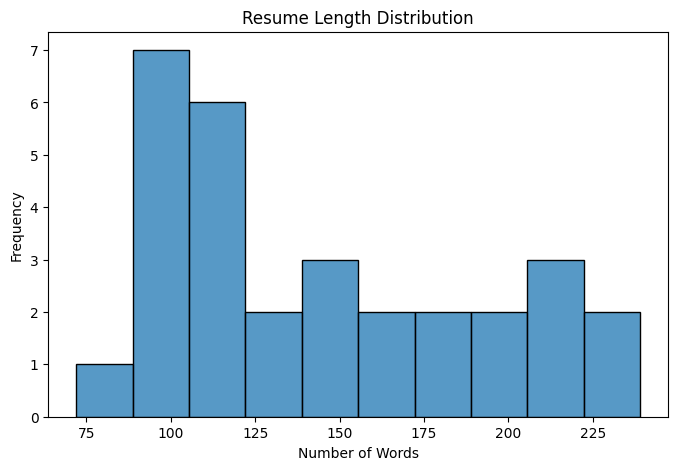

In [43]:
# Visualize the distribution of resume lengths

plt.figure(figsize=(8, 5))

sns.histplot(cv["resume_length"], bins=10)

plt.title("Resume Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [45]:
import ast

# Convert resume skills from text into Python lists
cv["skills_list"] = cv["clean_skills"].apply(ast.literal_eval)

cv[["target_position", "skills_list"]].head()

,target_position,skills_list
0,Senior Software Engineer,"[big data, hadoop, hive, python, mapreduce, sp..."
1,Machine Learning (ML) Engineer,"[data analysis, data analytics, business analy..."
2,"Executive/ Senior Executive- Trade Marketing, ...","[software development, machine learning, deep ..."
3,Business Development Executive,"[accounts payables, accounts receivables, acco..."
4,Senior iOS Engineer,"[analytical reasoning, compliance testing know..."


In [46]:
# Count how often each skill appears in the resumes

from collections import Counter

all_resume_skills = []

for skills in cv["skills_list"]:
    all_resume_skills.extend(skills)

resume_skill_counts = Counter(all_resume_skills)

resume_top_skills = pd.DataFrame(
    resume_skill_counts.most_common(10),
    columns=["Skill", "Count"]
)

resume_top_skills

,Skill,Count
0,python,15
1,machine learning,15
2,deep learning,10
3,javascript,7
4,c++,6
5,data analysis,6
6,html,6
7,css,6
8,java,5
9,mysql,5


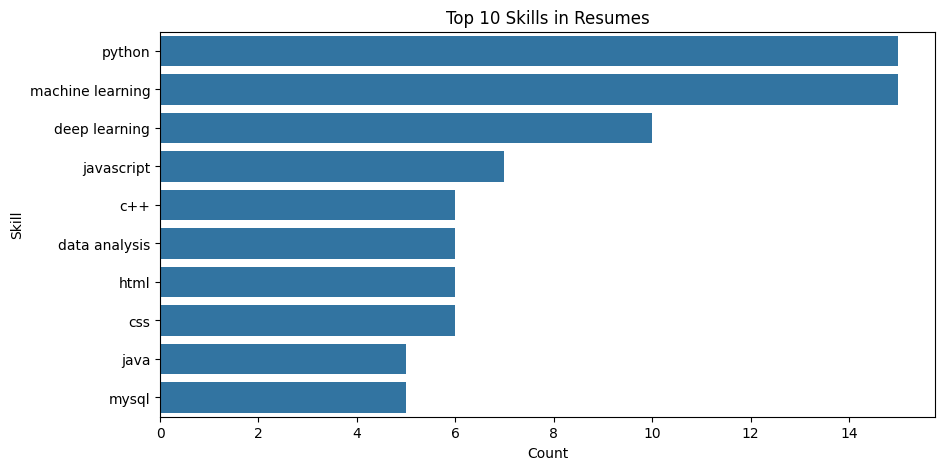

In [47]:
# Visualize the most common skills in resumes

plt.figure(figsize=(10, 5))

sns.barplot(
    data=resume_top_skills,
    x="Count",
    y="Skill"
)

plt.title("Top 10 Skills in Resumes")
plt.xlabel("Count")
plt.ylabel("Skill")

plt.show()

In [48]:
# Convert job skills from text into Python lists

jobs["skills_list"] = jobs["clean_skills"].apply(ast.literal_eval)

jobs[["job_title", "skills_list"]].head()

,job_title,skills_list
0,Director of Finance,"[financial management, accounting, gaap princi..."
1,Human Resources Manager,"[recruiting, talent management, compliance, em..."
2,Salesperson,"[sales, customer relationship management, tech..."
3,Business Development Manager,"[account management, client relationship manag..."
4,AOC Human Resources Project Manager,"[project management, human resources administr..."


In [49]:
# Count how often each skill is required by jobs

all_job_skills = []

for skills in jobs["skills_list"]:
    all_job_skills.extend(skills)

job_skill_counts = Counter(all_job_skills)

job_top_skills = pd.DataFrame(
    job_skill_counts.most_common(10),
    columns=["Skill", "Count"]
)

job_top_skills

,Skill,Count
0,adaptability,5
1,microsoft office suite,3
2,attention to detail,3
3,self-motivated,3
4,conflict resolution,3
5,employment law,3
6,relationship building,3
7,results oriented,2
8,confidentiality,2
9,performance management,2


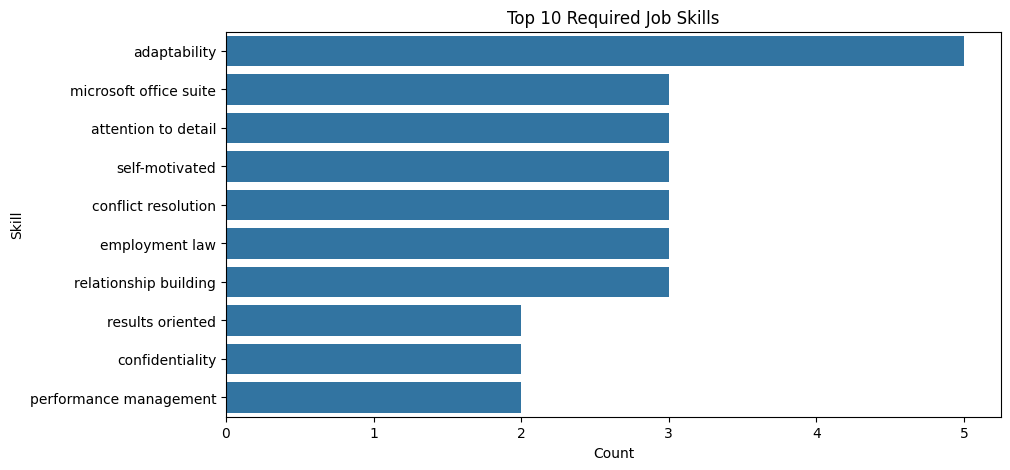

In [50]:
# Visualize the most common required job skills

plt.figure(figsize=(10, 5))

sns.barplot(
    data=job_top_skills,
    x="Count",
    y="Skill"
)

plt.title("Top 10 Required Job Skills")
plt.xlabel("Count")
plt.ylabel("Skill")

plt.show()

In [51]:
# Check the distribution of job categories

print(jobs["category"].value_counts())

category
HR                        3
INFORMATION-TECHNOLOGY    3
BUSINESS-DEVELOPMENT      2
FINANCE                   1
SALES                     1
Name: count, dtype: int64


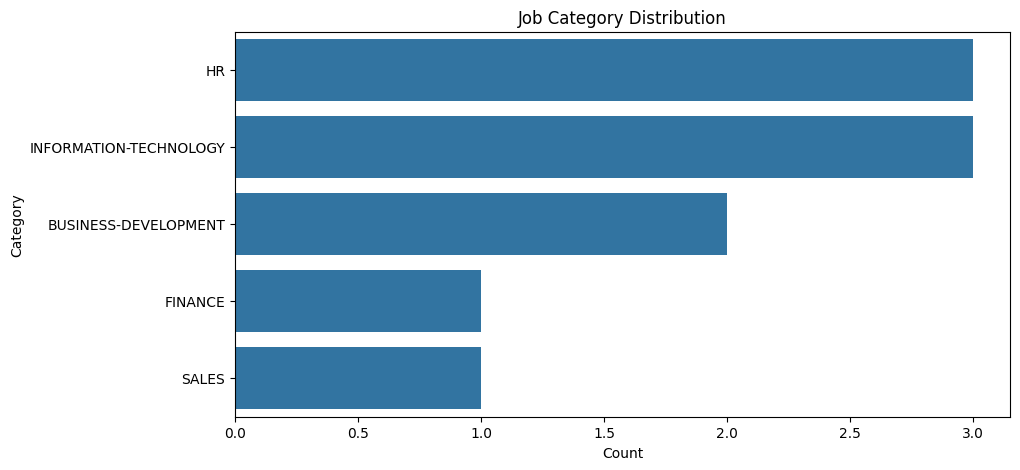

In [52]:
# Visualize job categories

plt.figure(figsize=(10, 5))

sns.countplot(
    data=jobs,
    y="category",
    order=jobs["category"].value_counts().index
)

plt.title("Job Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

AI/NLP Model

In [53]:
# Create a skill dictionary from resumes and job descriptions

all_skills = set()

for skills in cv["skills_list"]:
    all_skills.update(skills)

for skills in jobs["skills_list"]:
    all_skills.update(skills)

skill_dictionary = sorted(list(all_skills))

print("Number of unique skills:", len(skill_dictionary))
print("\nSample skills:")
print(skill_dictionary[:30])

Number of unique skills: 735

Sample skills:
['10key by touch', '2000', 'access', 'account management', 'accounting', 'accounting controls', 'accounting systems', 'accounts payable', 'accounts payables', 'accounts receivable', 'accounts receivables', 'adaptability', 'aderant/cms', 'administrative', 'administrative functions', 'aggressive', 'agile/scrum', 'algorithm design', 'amazon redshift', 'analytical aptitude', 'analytical reasoning', 'analytical thinking', 'and humidity', 'android development', 'annual reports', 'api', 'api design and documentation', 'applicant tracking systems', 'application development', 'application review']


Skill Extraction

In [ ]:
 # Install spaCy

%pip install spacy

Note: you may need to restart the kernel to use updated packages.


In [54]:
# Import spaCy and create an English NLP pipeline

import spacy

nlp = spacy.blank("en")

In [55]:
# Add EntityRuler to recognize skills

ruler = nlp.add_pipe("entity_ruler")

In [56]:
# Create patterns for all skills in the dictionary

patterns = []

for skill in skill_dictionary:
    patterns.append({
        "label": "SKILL",
        "pattern": skill
    })

ruler.add_patterns(patterns)

print("Number of skill patterns:", len(patterns))

Number of skill patterns: 735


In [57]:
# Extract skills from text using spaCy

def extract_skills(text):

    doc = nlp(text)

    skills = []

    for ent in doc.ents:
        if ent.label_ == "SKILL":
            skills.append(ent.text)

    return list(set(skills))

In [58]:
# Test skill extraction on one resume

extracted_resume_skills = extract_skills(
    cv.loc[0, "processed_resume"]
)

print("Extracted Resume Skills:")
print(extracted_resume_skills)

Extracted Resume Skills:
['dbms', 'talend', 'core java', 'rdbms', 'development', 'services', 'data structures', 'spark', 'troubleshooting', 'engineer', 'amazon redshift', 'python', 'c++', 'hive', 'big data', 'mapreduce', 'technical support', 'yarn', 'data science', 'hdfs', 'microsoft azure', 'hadoop', 'database', 'cloud', 'informatica', 'machine learning', 'java']


In [59]:
# Extract skills from one job description

extracted_job_skills = extract_skills(
    jobs.loc[0, "processed_job"]
)

print("Extracted Job Skills:")
print(extracted_job_skills)

Extracted Job Skills:
['banking', 'hardware', 'processes', 'direction', 'self motivated', 'drafting', 'development', 'results oriented', 'finance', 'services', 'asset', 'delivery', 'budgeting', 'pos systems', 'network', 'administrative', 'accounts receivable', 'quality', 'meetings', 'written', 'financial', 'accounts payable', 'microsoft office suite', 'budget processes', 'gaap principles', 'forecasting', 'financial statement preparation', 'insurance', 'compliance', 'internal controls', 'bi', 'accounting', 'investment oversight', 'tax', 'budget', 'developing', 'safety', 'cash flow management', 'contracts', 'raiser s edge software', 'policies', 'confidentiality', 'risk management', 'driving', 'financial management']


In [60]:
# Compare extracted resume skills with extracted job skills

matched_skills = list(
    set(extracted_resume_skills) & set(extracted_job_skills)
)

missing_skills = list(
    set(extracted_job_skills) - set(extracted_resume_skills)
)

print("Matched Skills:")
print(matched_skills)

print("\nMissing Skills:")
print(missing_skills)

Matched Skills:
['development', 'services']

Missing Skills:
['banking', 'hardware', 'processes', 'direction', 'self motivated', 'drafting', 'results oriented', 'finance', 'asset', 'delivery', 'budgeting', 'pos systems', 'network', 'administrative', 'accounts receivable', 'quality', 'meetings', 'written', 'financial', 'accounts payable', 'microsoft office suite', 'budget processes', 'gaap principles', 'forecasting', 'financial statement preparation', 'insurance', 'compliance', 'internal controls', 'bi', 'accounting', 'investment oversight', 'tax', 'budget', 'developing', 'safety', 'cash flow management', 'contracts', 'raiser s edge software', 'policies', 'confidentiality', 'risk management', 'driving', 'financial management']


In [61]:
# Remove generic words from extracted skills

generic_skills = {
    "development",
    "services",
    "engineer",
    "database",
    "written",
    "direction",
    "financial"
}

extracted_resume_skills = [
    skill for skill in extracted_resume_skills
    if skill not in generic_skills
]

extracted_job_skills = [
    skill for skill in extracted_job_skills
    if skill not in generic_skills
]

print("Cleaned Resume Skills:")
print(extracted_resume_skills)

print("\nCleaned Job Skills:")
print(extracted_job_skills)

Cleaned Resume Skills:
['dbms', 'talend', 'core java', 'rdbms', 'data structures', 'spark', 'troubleshooting', 'amazon redshift', 'python', 'c++', 'hive', 'big data', 'mapreduce', 'technical support', 'yarn', 'data science', 'hdfs', 'microsoft azure', 'hadoop', 'cloud', 'informatica', 'machine learning', 'java']

Cleaned Job Skills:
['banking', 'hardware', 'processes', 'self motivated', 'drafting', 'results oriented', 'finance', 'asset', 'delivery', 'budgeting', 'pos systems', 'network', 'administrative', 'accounts receivable', 'quality', 'meetings', 'accounts payable', 'microsoft office suite', 'budget processes', 'gaap principles', 'forecasting', 'financial statement preparation', 'insurance', 'compliance', 'internal controls', 'bi', 'accounting', 'investment oversight', 'tax', 'budget', 'developing', 'safety', 'cash flow management', 'contracts', 'raiser s edge software', 'policies', 'confidentiality', 'risk management', 'driving', 'financial management']


In [62]:
# Compare cleaned extracted skills

matched_skills = list(
    set(extracted_resume_skills) & set(extracted_job_skills)
)

missing_skills = list(
    set(extracted_job_skills) - set(extracted_resume_skills)
)

print("Matched Skills:")
print(matched_skills)

print("\nMissing Skills:")
print(missing_skills)

Matched Skills:
[]

Missing Skills:
['banking', 'hardware', 'processes', 'self motivated', 'drafting', 'results oriented', 'finance', 'asset', 'delivery', 'budgeting', 'pos systems', 'network', 'administrative', 'accounts receivable', 'quality', 'meetings', 'accounts payable', 'microsoft office suite', 'budget processes', 'gaap principles', 'forecasting', 'financial statement preparation', 'insurance', 'compliance', 'internal controls', 'bi', 'accounting', 'investment oversight', 'tax', 'budget', 'developing', 'safety', 'cash flow management', 'contracts', 'raiser s edge software', 'policies', 'confidentiality', 'risk management', 'driving', 'financial management']


In [63]:
# Calculate skill match percentage

if len(extracted_job_skills) > 0:
    skill_match_percentage = (
        len(matched_skills) / len(extracted_job_skills)
    ) * 100
else:
    skill_match_percentage = 0

print("Skill Match Percentage:", round(skill_match_percentage, 2), "%")

Skill Match Percentage: 0.0 %


TF-IDF + Cosine Similarity

In [64]:
# Import TF-IDF and cosine similarity tools

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [65]:
# Install scikit-learn

%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [66]:
# Analyze one resume against one job using the optimized skill extractor

def analyze_match(resume_index, job_index):

    # Extract skills using the optimized extractor
    resume_skills = extract_skills_optimized(
        cv.loc[resume_index, "processed_resume"]
    )

    job_skills = extract_skills_optimized(
        jobs.loc[job_index, "processed_job"]
    )

    # Find matched and missing skills
    matched = list(
        set(resume_skills) & set(job_skills)
    )

    missing = list(
        set(job_skills) - set(resume_skills)
    )

    # Calculate skill match percentage
    if len(job_skills) > 0:
        skill_score = (
            len(matched) / len(job_skills)
        ) * 100
    else:
        skill_score = 0

    # Prepare text for TF-IDF
    documents = [
        cv.loc[resume_index, "final_processed_resume"],
        jobs.loc[job_index, "final_processed_job"]
    ]

    # Convert text into TF-IDF vectors
    tfidf = TfidfVectorizer()

    matrix = tfidf.fit_transform(documents)

    # Calculate cosine similarity
    similarity = cosine_similarity(
        matrix[0:1],
        matrix[1:2]
    )[0][0] * 100

    # Store results
    result = {
        "resume_position": cv.loc[resume_index, "target_position"],
        "job_title": jobs.loc[job_index, "job_title"],
        "matched_skills": matched,
        "missing_skills": missing,
        "skill_match_percentage": round(skill_score, 2),
        "text_similarity_percentage": round(similarity, 2)
    }

    # Display results
    print("Resume:", result["resume_position"])
    print("Job:", result["job_title"])

    print("\nMatched Skills:")
    print(result["matched_skills"])

    print("\nMissing Skills:")
    print(result["missing_skills"])

    print(
        "\nSkill Match Percentage:",
        result["skill_match_percentage"],
        "%"
    )

    print(
        "Text Similarity Percentage:",
        result["text_similarity_percentage"],
        "%"
    )

    return result

In [67]:
import spacy

# 1. Rebuild the skill dictionaries from your loaded data
all_skills = set()
for skills in cv["skills_list"]:
    all_skills.update(skills)
for skills in jobs["skills_list"]:
    all_skills.update(skills)

generic_skills = {"development", "services", "engineer", "database", "written",
                  "direction", "financial", "processes", "quality", "delivery",
                  "network", "meetings", "developing"}
optimized_skill_dictionary = [s for s in all_skills if s not in generic_skills]

# 2. Rebuild the optimized NLP pipeline
optimized_nlp = spacy.blank("en")
optimized_ruler = optimized_nlp.add_pipe("entity_ruler")

optimized_patterns = [{"label": "SKILL", "pattern": skill} for skill in optimized_skill_dictionary]
optimized_ruler.add_patterns(optimized_patterns)

# 3. Define the missing function
def extract_skills_optimized(text):
    doc = optimized_nlp(text)
    skills = [ent.text for ent in doc.ents if ent.label_ == "SKILL"]
    return list(set(skills))

In [68]:
# Test the analyzer

analyze_match(3, 3)


Resume: Business Development Executive
Job: Business Development Manager

Matched Skills:
['sourcing', 'business development', 'clients']

Missing Skills:
['client relationship management', 'account management', 'recruitment', 'contractor staffing', 'self motivated', 'aggressive', 'technical recruitment', 'articulate', 'placing', 'it staffing', 'energetic', 'target oriented', 'client']

Skill Match Percentage: 18.75 %
Text Similarity Percentage: 11.68 %


{'resume_position': 'Business Development Executive',
 'job_title': 'Business Development Manager',
 'matched_skills': ['sourcing', 'business development', 'clients'],
 'missing_skills': ['client relationship management',
  'account management',
  'recruitment',
  'contractor staffing',
  'self motivated',
  'aggressive',
  'technical recruitment',
  'articulate',
  'placing',
  'it staffing',
  'energetic',
  'target oriented',
  'client'],
 'skill_match_percentage': 18.75,
 'text_similarity_percentage': np.float64(11.68)}

In [69]:
# Evaluate extracted resume skills using precision, recall, and F1-score

from sklearn.metrics import precision_score, recall_score, f1_score

In [70]:
# Compare extracted skills with the reference skills for one resume

reference_skills = set(
    ast.literal_eval(cv.loc[0, "clean_skills"])
)

predicted_skills = set(
    extract_skills(cv.loc[0, "processed_resume"])
)

all_eval_skills = list(reference_skills | predicted_skills)

y_true = [
    1 if skill in reference_skills else 0
    for skill in all_eval_skills
]

y_pred = [
    1 if skill in predicted_skills else 0
    for skill in all_eval_skills
]

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Precision:", round(precision, 2))
print("Recall:", round(recall, 2))
print("F1-score:", round(f1, 2))

Precision: 0.78
Recall: 1.0
F1-score: 0.88


In [71]:
# Evaluate the skill extractor on multiple resumes

precision_scores = []
recall_scores = []
f1_scores = []

for i in range(len(cv)):

    reference_skills = set(
        ast.literal_eval(cv.loc[i, "clean_skills"])
    )

    predicted_skills = set(
        extract_skills(cv.loc[i, "processed_resume"])
    )

    all_eval_skills = list(reference_skills | predicted_skills)

    y_true = [
        1 if skill in reference_skills else 0
        for skill in all_eval_skills
    ]

    y_pred = [
        1 if skill in predicted_skills else 0
        for skill in all_eval_skills
    ]

    precision_scores.append(
        precision_score(y_true, y_pred, zero_division=0)
    )

    recall_scores.append(
        recall_score(y_true, y_pred, zero_division=0)
    )

    f1_scores.append(
        f1_score(y_true, y_pred, zero_division=0)
    )

print("Average Precision:", round(sum(precision_scores) / len(precision_scores), 2))
print("Average Recall:", round(sum(recall_scores) / len(recall_scores), 2))
print("Average F1-score:", round(sum(f1_scores) / len(f1_scores), 2))

Average Precision: 0.76
Average Recall: 0.98
Average F1-score: 0.85


In [72]:
# Remove generic terms from the skill dictionary

generic_skills = {
    "development",
    "services",
    "engineer",
    "database",
    "written",
    "direction",
    "financial",
    "processes",
    "quality",
    "delivery",
    "network",
    "meetings",
    "developing"
}

optimized_skill_dictionary = [
    skill for skill in skill_dictionary
    if skill not in generic_skills
]

print("Original skills:", len(skill_dictionary))
print("Optimized skills:", len(optimized_skill_dictionary))

Original skills: 735
Optimized skills: 722


In [73]:
# Create a new optimized spaCy skill extractor

optimized_nlp = spacy.blank("en")

optimized_ruler = optimized_nlp.add_pipe("entity_ruler")

optimized_patterns = []

for skill in optimized_skill_dictionary:
    optimized_patterns.append({
        "label": "SKILL",
        "pattern": skill
    })

optimized_ruler.add_patterns(optimized_patterns)

print("Optimized skill patterns:", len(optimized_patterns))

Optimized skill patterns: 722


In [74]:
# Extract skills using the optimized dictionary

def extract_skills_optimized(text):

    doc = optimized_nlp(text)

    skills = []

    for ent in doc.ents:
        if ent.label_ == "SKILL":
            skills.append(ent.text)

    return list(set(skills))

In [75]:
# Evaluate the optimized skill extractor on multiple resumes

optimized_precision_scores = []
optimized_recall_scores = []
optimized_f1_scores = []

for i in range(len(cv)):

    reference_skills = set(
        ast.literal_eval(cv.loc[i, "clean_skills"])
    )

    predicted_skills = set(
        extract_skills_optimized(cv.loc[i, "processed_resume"])
    )

    all_eval_skills = list(reference_skills | predicted_skills)

    y_true = [
        1 if skill in reference_skills else 0
        for skill in all_eval_skills
    ]

    y_pred = [
        1 if skill in predicted_skills else 0
        for skill in all_eval_skills
    ]

    optimized_precision_scores.append(
        precision_score(y_true, y_pred, zero_division=0)
    )

    optimized_recall_scores.append(
        recall_score(y_true, y_pred, zero_division=0)
    )

    optimized_f1_scores.append(
        f1_score(y_true, y_pred, zero_division=0)
    )

optimized_precision = sum(optimized_precision_scores) / len(optimized_precision_scores)
optimized_recall = sum(optimized_recall_scores) / len(optimized_recall_scores)
optimized_f1 = sum(optimized_f1_scores) / len(optimized_f1_scores)

print("Optimized Average Precision:", round(optimized_precision, 2))
print("Optimized Average Recall:", round(optimized_recall, 2))
print("Optimized Average F1-score:", round(optimized_f1, 2))

Optimized Average Precision: 0.79
Optimized Average Recall: 0.97
Optimized Average F1-score: 0.86


In [76]:
# Compare model performance before and after optimization

print("Before Optimization")
print("Precision: 0.76")
print("Recall: 0.98")
print("F1-score: 0.85")

print("\nAfter Optimization")
print("Precision:", round(optimized_precision, 2))
print("Recall:", round(optimized_recall, 2))
print("F1-score:", round(optimized_f1, 2))

Before Optimization
Precision: 0.76
Recall: 0.98
F1-score: 0.85

After Optimization
Precision: 0.79
Recall: 0.97
F1-score: 0.86


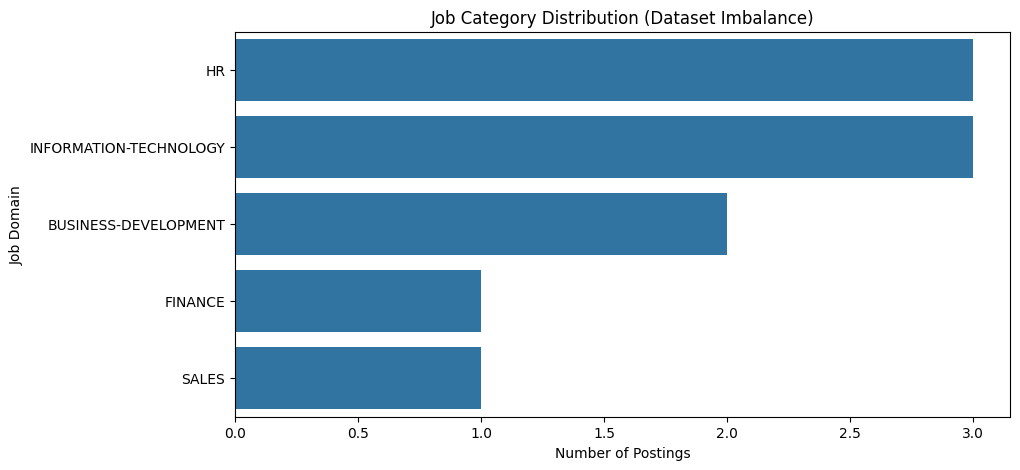


--- Top Required Skills per Job Domain ---

BUSINESS-DEVELOPMENT:
  - account management: 2
  - self-motivated: 2
  - client relationship management: 1
  - revenue target accountability: 1
  - business development: 1

FINANCE:
  - financial management: 1
  - accounting: 1
  - gaap principles: 1
  - budgeting: 1
  - forecasting: 1

HR:
  - employment law: 3
  - conflict resolution: 2
  - performance management: 2
  - adaptability: 2
  - critical thinking: 2

INFORMATION-TECHNOLOGY:
  - adaptability: 2
  - erp administration: 1
  - technical support: 1
  - data management: 1
  - network access control: 1

SALES:
  - sales: 1
  - customer relationship management: 1
  - technical skills: 1
  - presentation skills: 1
  - merchandising: 1


In [77]:
# Investigate dataset imbalance
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

plt.figure(figsize=(10, 5))
sns.countplot(data=jobs, y='category', order=jobs['category'].value_counts().index)
plt.title("Job Category Distribution (Dataset Imbalance)")
plt.xlabel("Number of Postings")
plt.ylabel("Job Domain")
plt.show()

# TASK 3: Analyze top required skills per job domain
print("\n--- Top Required Skills per Job Domain ---")
domain_skills = jobs.groupby('category')['skills_list'].sum()

for domain, skills in domain_skills.items():
    print(f"\n{domain}:")
    skill_counts = Counter(skills)
    for skill, count in skill_counts.most_common(5):
        print(f"  - {skill}: {count}")

### EDA Report & Findings
* **Dataset Imbalance:** The dataset leans heavily toward HR and IT categories. Future iterations will require expanding the Finance and Sales data to prevent model bias.
* **Skill Frequency:** Broad skills like Python, Machine Learning, and adaptability dominate the requirements.
* **Parsing Bottlenecks:** PDF layouts with columns or non-standard bullet points cause the regex extractor to misclassify Experience and Education blocks.